
# 🎓 Student Performance Prediction Assignment
Applied AI & Machine Learning (CS-333)  
Instructor: Dr. Abbas Hussain  

---

## Objective
Predict **Performance Index** using multiple ML regression models.


# **Name: Muhammad Ahzam**
# **Roll Number: ME - 1957**
# **Section: A**


## Import Libraries

In [128]:
# Import required libraries
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

## Load Dataset

In [129]:
# Load dataset
# Using the link from GitHub
url = 'https://raw.githubusercontent.com/123saad321/MLdatasets/refs/heads/main/Student_Performance.csv'
df = pd.read_csv(url)

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Exploratory Data Analysis

In [130]:
# Check Type and info
df.dtypes
df.info()
df.shape
print(df.describe().to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB
       Hours Studied  Previous Scores   Sleep Hours  Sample Question Papers Practiced  Performance Index
count   10000.000000     10000.000000  10000.000000                      10000.000000       10000.000000
mean        4.992900        69.445700      6.530600                          4.583300          55.224800
std       

In [131]:
# Check missing values
print(df.isnull().sum())
df.info()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [132]:
# Check Duplicate values
df.shape
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (127, 6)


In [133]:
# Remove duplicates
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     9873 non-null   int64  
 1   Previous Scores                   9873 non-null   int64  
 2   Extracurricular Activities        9873 non-null   object 
 3   Sleep Hours                       9873 non-null   int64  
 4   Sample Question Papers Practiced  9873 non-null   int64  
 5   Performance Index                 9873 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 539.9+ KB


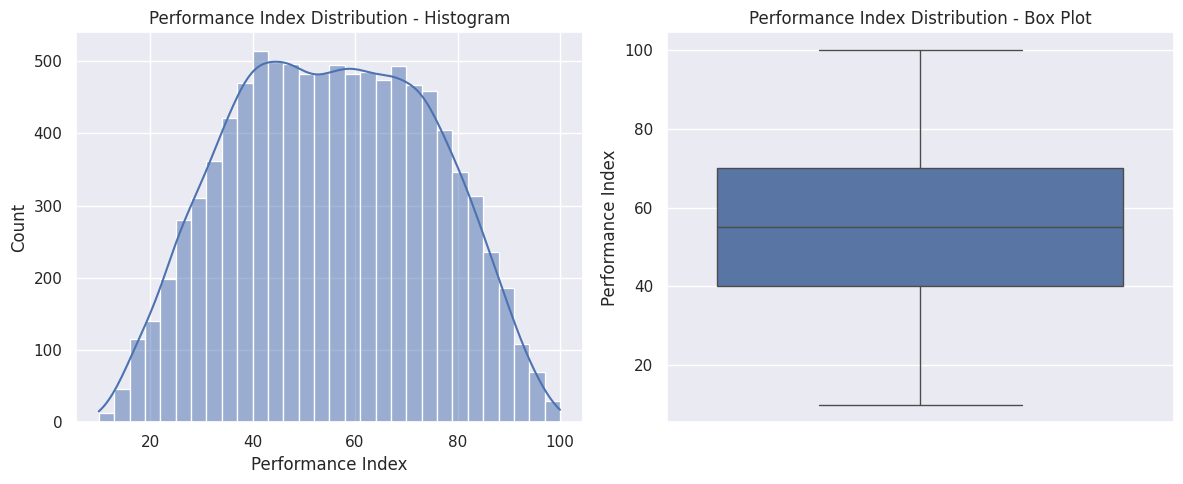

Performance Index Skewness: -0.00
Performance Index Kurotsis: -0.86


In [134]:
# Distibution Plot
# Visualizing the Performance Index distribution.

plt.figure(figsize=(12, 5)) #Setting the figure size.

# Left: Histogram
plt.subplot(1, 2, 1)
sns.histplot(df["Performance Index"], kde=True, bins=30)
plt.title("Performance Index Distribution - Histogram")
plt.xlabel("Performance Index", fontsize=12)

# Right: Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df["Performance Index"])
plt.title("Performance Index Distribution - Box Plot")
plt.ylabel("Performance Index", fontsize=12)

plt.tight_layout()
plt.show()

# Calculating skewness and kurtosis of the price distribution.
skewness = df["Performance Index"].skew()
kurtosis = df["Performance Index"].kurt()
print(f"Performance Index Skewness: {skewness:.2f}")
print(f"Performance Index Kurotsis: {kurtosis:.2f}")

## Encoding (if needed)

In [135]:
# Encode categorical columns if any
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Extracurricular Activities"
]
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [136]:
df1 = df_encoded.copy()
df1.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


## Visualization

<Axes: >

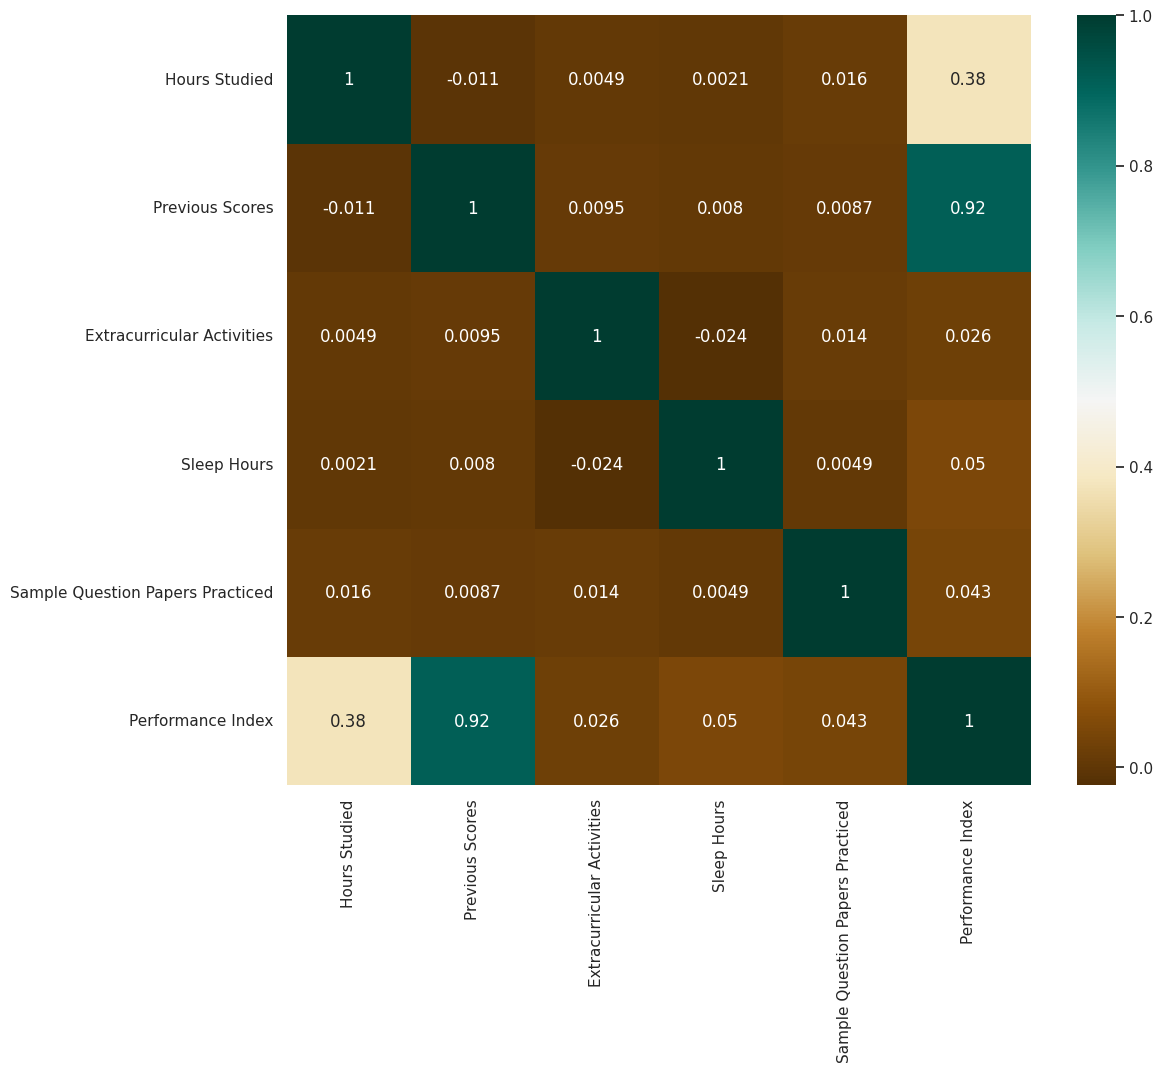

In [137]:
# Heatmap
c = df1.corr()
plt.figure(figsize=(12,10))
sns.heatmap(c,cmap="BrBG",annot=True)

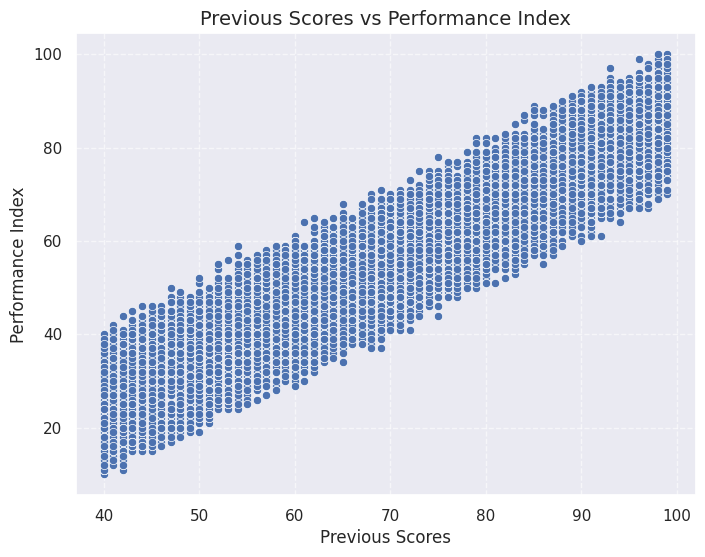

In [138]:
# Examining the relationship between Previous Scores and Performance Index.

# Creating a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x="Previous Scores", y="Performance Index", data=df1)
plt.title(f"Previous Scores vs Performance Index", fontsize=14)
plt.xlabel("Previous Scores", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

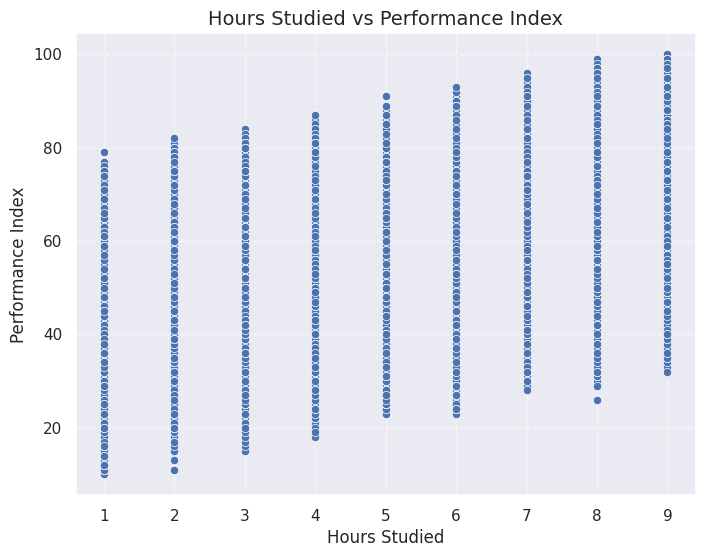

In [139]:
# Examining the relationship between Hours Studied and Performance Index.

# Creating a scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x = "Hours Studied", y = "Performance Index", data=df1)
plt.title(f"Hours Studied vs Performance Index", fontsize=14)
plt.xlabel("Hours Studied", fontsize=12)
plt.ylabel("Performance Index", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Correlation Analysis

In [140]:
# Compute correlation matrix
correlation_matrix = df1.corr()
print("Correlation Matrix:")
print(correlation_matrix.to_string())

Correlation Matrix:
                                  Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  Sample Question Papers Practiced  Performance Index
Hours Studied                          1.000000        -0.010676                    0.004899     0.002131                          0.015740           0.375332
Previous Scores                       -0.010676         1.000000                    0.009534     0.007975                          0.008719           0.915135
Extracurricular Activities             0.004899         0.009534                    1.000000    -0.024008                          0.013839           0.026075
Sleep Hours                            0.002131         0.007975                   -0.024008     1.000000                          0.004907           0.050352
Sample Question Papers Practiced       0.015740         0.008719                    0.013839     0.004907                          1.000000           0.043436
Performance Index         

## Feature Selection

In [141]:
X = df1.drop("Performance Index", axis=1) #Features
y = df1["Performance Index"] #Label

## Train-Test Split

In [142]:
from sklearn.model_selection import train_test_split # For splitting the dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Feature Scaling (If needed)

In [143]:
# Applying Feature Scaling.
from sklearn.preprocessing import StandardScaler
# Only numerical features should be scaled.
numeric_vars = ["Hours Studied",	"Previous Scores", "Sleep Hours",	"Sample Question Papers Practiced"]
scaler = StandardScaler()
X_train[numeric_vars] = scaler.fit_transform(X_train[numeric_vars])
X_test[numeric_vars] = scaler.transform(X_test[numeric_vars])

print("--- First 5 Rows of Scaled Training Data ---")
print(X_train[numeric_vars].head().to_markdown(index=False, numalign="left", stralign="left", floatfmt=".2f"))


# ONLY FOR SVRR
# Scale y
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

--- First 5 Rows of Scaled Training Data ---
| Hours Studied   | Previous Scores   | Sleep Hours   | Sample Question Papers Practiced   |
|:----------------|:------------------|:--------------|:-----------------------------------|
| 0.78            | 0.84              | -1.49         | -0.56                              |
| 0.39            | 0.73              | -0.32         | -1.61                              |
| 1.17            | 0.79              | 1.44          | 0.49                               |
| 0.39            | -0.54             | -0.32         | 0.49                               |
| -0.77           | 1.42              | 0.27          | -1.61                              |


## Apply Regression Models (LR, SVR, Decision Tree,Random Forest, KNN)

In [144]:
#Apply models

In [145]:
# Linear Regression (LR)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Training Timer
start_train = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
end_train = time.time()

# Testing Timer
start_test = time.time()
y_pred_lr = lr.predict(X_test)
end_test = time.time()


# R-squared
r2_lr = r2_score(y_test, y_pred_lr)
# RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
# MAE
mae_lr = mean_absolute_error(y_test, y_pred_lr)
# Training Time
train_time_lr = end_train - start_train
# Testing Time
test_time_lr = end_test - start_test


print("LR Model Performance:\n")
print("R² Score:", round(r2_lr, 4))
print("RMSE:", round(rmse_lr, 4))
print("MAE:", round(mae_lr, 4))
print("Training Time:", round(train_time_lr, 4), "seconds")
print("Testing Time:", round(test_time_lr, 4), "seconds")

LR Model Performance:

R² Score: 0.9882
RMSE: 2.0799
MAE: 1.6462
Training Time: 0.0053 seconds
Testing Time: 0.002 seconds


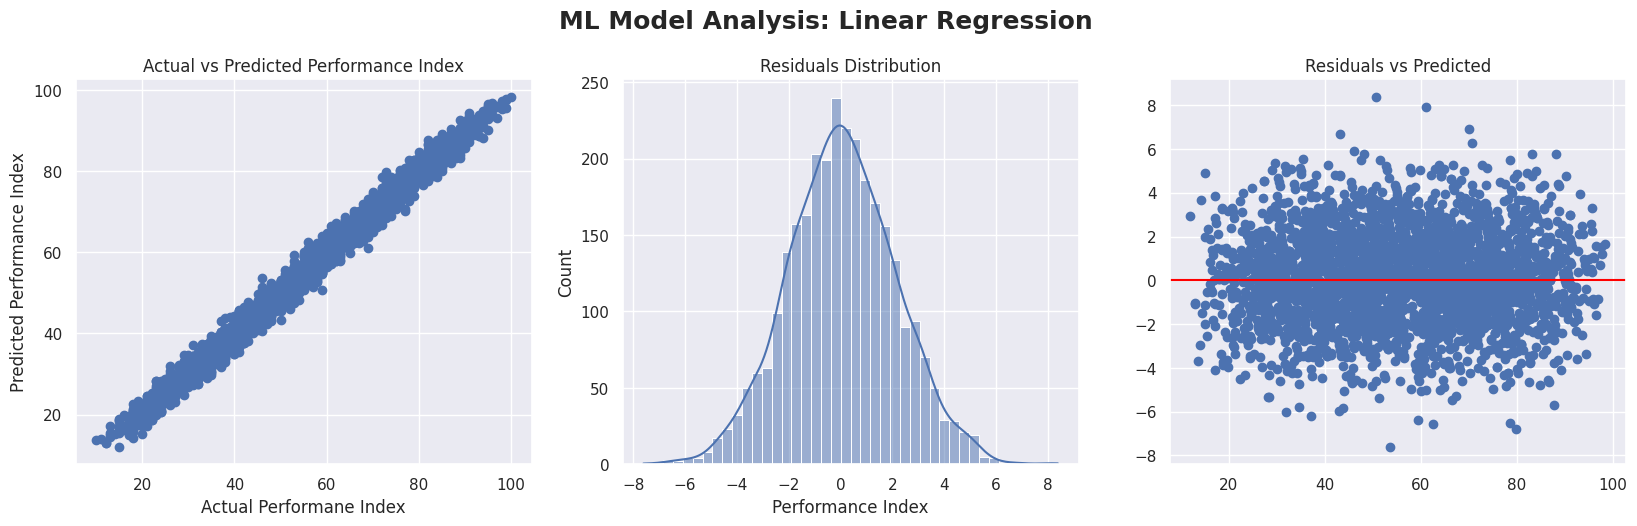

In [146]:
# Visualizing Linear Regression (LR)

plt.figure(figsize=(20,5))
plt.suptitle("ML Model Analysis: Linear Regression", fontsize=18, fontweight='bold', y=1.02)

# Scatter Plot
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Performane Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")

# Calculate residuals
residuals_lr = y_test - y_pred_lr

# Histogram of residuals
plt.subplot(1,3,2)
sns.histplot(residuals_lr, kde=True)
plt.title("Residuals Distribution")

# Residuals vs Predicted
plt.subplot(1,3,3)
plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.show()

In [147]:
# Support Vector Regression (SVR)
from sklearn.svm import SVR

# Training Timer
start_train = time.time() # Start Training Timer
svr = SVR(kernel='rbf', C=100, gamma=0.01)
svr.fit(X_train, y_train_scaled)
end_train = time.time() # End Training Timer

# Testing Timer
start_test = time.time() # Start Testing Timer
y_pred_svr = svr.predict(X_test)
# Convert back to original scale
y_pred_svr = scaler_y.inverse_transform(y_pred_svr.reshape(-1,1)).flatten()
end_test = time.time() # End Testing Timer


r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
train_time_svr = end_train - start_train
test_time_svr = end_test - start_test

print("SVR Model Performance\n")
print("R² Score:", round(r2_svr, 4))
print("RMSE:", round(rmse_svr, 4))
print("MAE:", round(mae_svr, 4))
print("Training Time:", round(train_time_svr, 4), "seconds")
print("Testing Time:", round(test_time_svr, 4), "seconds")

SVR Model Performance

R² Score: 0.9881
RMSE: 2.0859
MAE: 1.6498
Training Time: 4.1665 seconds
Testing Time: 0.3327 seconds


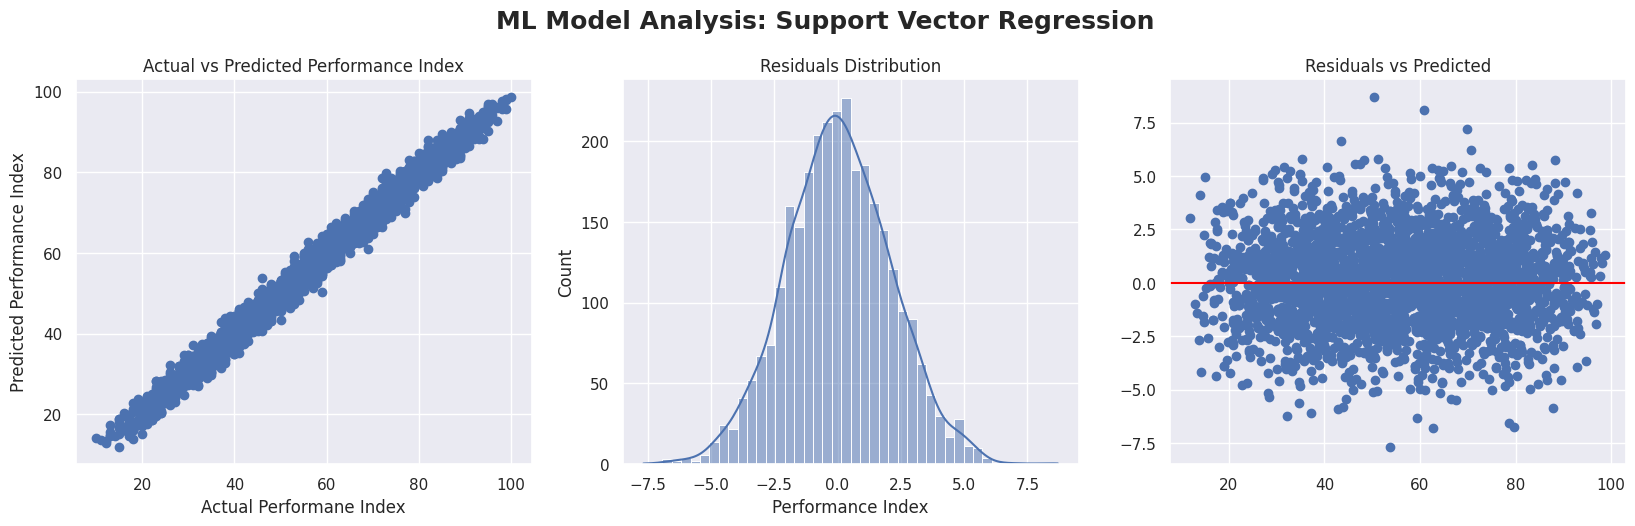

In [148]:
# Visualizing Support Vector Regression (SVR)

plt.figure(figsize=(20,5))
plt.suptitle("ML Model Analysis: Support Vector Regression", fontsize=18, fontweight='bold', y=1.02)

# Scatter Plot
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_svr)
plt.xlabel("Actual Performane Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")

# Calculate residuals
residuals_svr = y_test - y_pred_svr

# Histogram of residuals
plt.subplot(1,3,2)
sns.histplot(residuals_svr, kde=True)
plt.title("Residuals Distribution")

# Residuals vs Predicted
plt.subplot(1,3,3)
plt.scatter(y_pred_svr, residuals_svr)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.show()

In [149]:
# Decision Tree Regressor (DTR)
from sklearn.tree import DecisionTreeRegressor

# Training Timer
start_train = time.time()
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
end_train = time.time()

# Testing Timer
start_test = time.time()
y_pred_dt = dt.predict(X_test)
end_test = time.time()

# Metrics
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
train_time_dt = end_train - start_train
test_time_dt = end_test - start_test

print("Decision Tree Performance:\n")
print("R² Score:", round(r2_dt, 4))
print("RMSE:", round(rmse_dt, 4))
print("MAE:", round(mae_dt, 4))
print("Training Time:", round(train_time_dt, 4), "seconds")
print("Testing Time:", round(test_time_dt, 4), "seconds")

Decision Tree Performance:

R² Score: 0.9745
RMSE: 3.0521
MAE: 2.4371
Training Time: 0.031 seconds
Testing Time: 0.0026 seconds


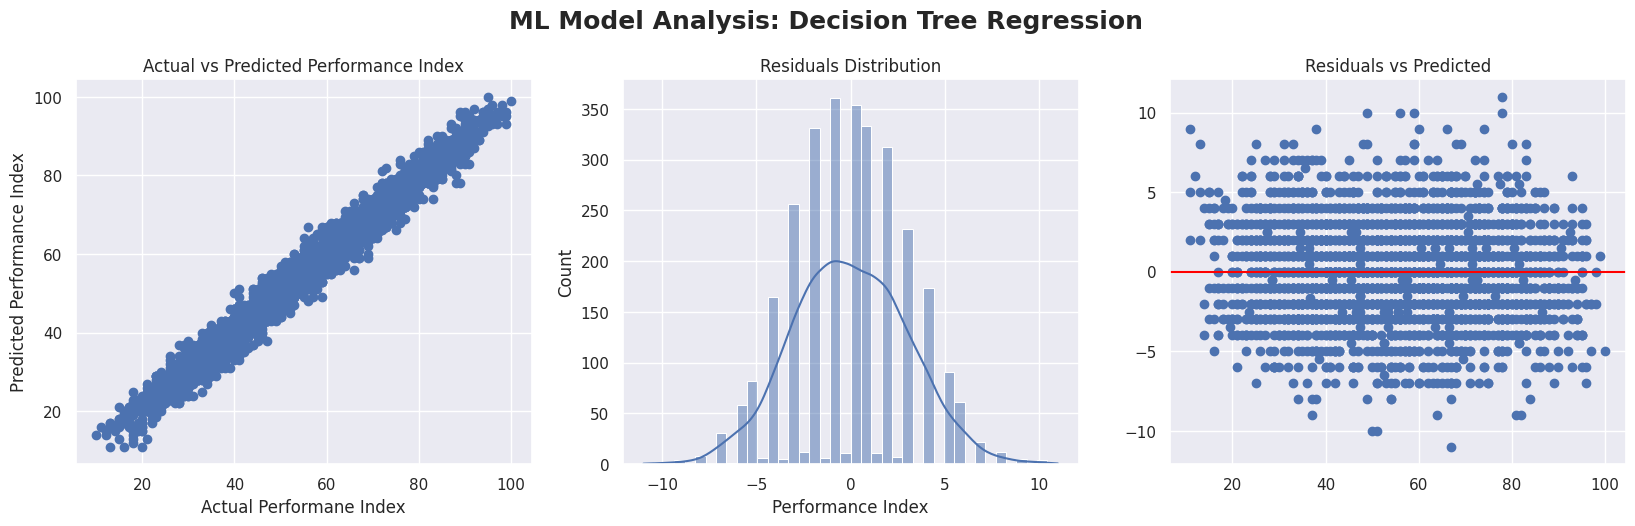

In [150]:
# Visualizing Decision Tree Regression (DTR)

plt.figure(figsize=(20,5))
plt.suptitle("ML Model Analysis: Decision Tree Regression", fontsize=18, fontweight='bold', y=1.02)

# Scatter Plot
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Performane Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")

# Calculate residuals
residuals_dt = y_test - y_pred_dt

# Histogram of residuals
plt.subplot(1,3,2)
sns.histplot(residuals_dt, kde=True)
plt.title("Residuals Distribution")

# Residuals vs Predicted
plt.subplot(1,3,3)
plt.scatter(y_pred_dt, residuals_dt)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.show()

In [151]:
# Random Forest Regressor (RF)
from sklearn.ensemble import RandomForestRegressor

# Training Timer
start_train = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
end_train = time.time()

# Testing Timer
start_test = time.time()
y_pred_rf = rf.predict(X_test)
end_test = time.time()

# R-squared
r2_rf = r2_score(y_test, y_pred_rf)
# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)
# Training Time
train_time_rf = end_train - start_train
# Testing Time
test_time_rf = end_test - start_test

print("Random Forest Performance:\n")
print("R² Score:", round(r2_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("MAE:", round(mae_rf, 4))
print("Training Time:", round(train_time_rf, 4), "seconds")
print("Testing Time:", round(test_time_rf, 4), "seconds")

Random Forest Performance:

R² Score: 0.9846
RMSE: 2.3736
MAE: 1.8929
Training Time: 1.4687 seconds
Testing Time: 0.0841 seconds


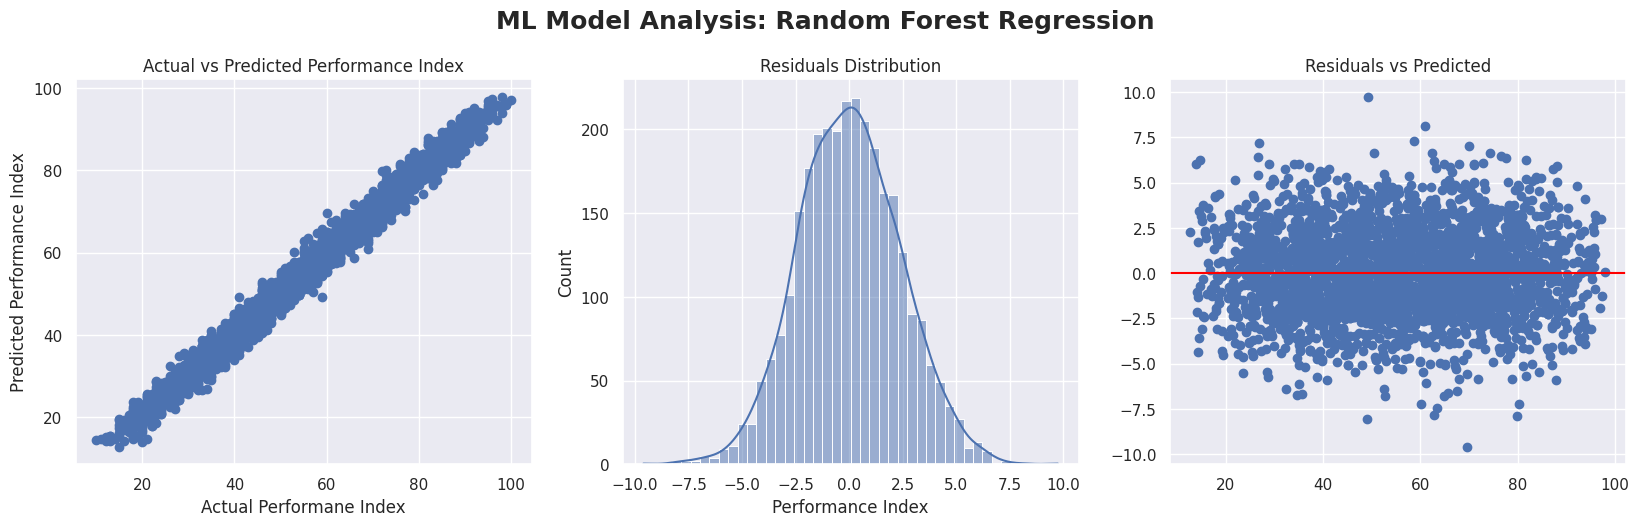

In [152]:
# Visualizing Random Forest Regression (RF)

plt.figure(figsize=(20,5))
plt.suptitle("ML Model Analysis: Random Forest Regression", fontsize=18, fontweight='bold', y=1.02)

# Scatter Plot
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Performane Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")

# Calculate residuals
residuals_rf = y_test - y_pred_rf

# Histogram of residuals
plt.subplot(1,3,2)
sns.histplot(residuals_rf, kde=True)
plt.title("Residuals Distribution")

# Residuals vs Predicted
plt.subplot(1,3,3)
plt.scatter(y_pred_rf, residuals_rf)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.show()

In [153]:
# K-Nearest Neighbors Regressor (k-NN)
from sklearn.neighbors import KNeighborsRegressor

# Training Timer
start_train = time.time()
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
end_train = time.time()

# Testing Timer
start_test = time.time()
y_pred_knn = knn.predict(X_test)
end_test = time.time()

# R-squared
r2_knn = r2_score(y_test, y_pred_knn)
# RMSE
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
# MAE
mae_knn = mean_absolute_error(y_test, y_pred_knn)
# Training Time
train_time_knn = end_train - start_train
# Testing Time
test_time_knn = end_test - start_test

print("KNN Performance:\n")
print("R² Score:", round(r2_knn, 4))
print("RMSE:", round(rmse_knn, 4))
print("MAE:", round(mae_knn, 4))
print("Training Time:", round(train_time_knn, 4), "seconds")
print("Testing Time:", round(test_time_knn, 4), "seconds")

KNN Performance:

R² Score: 0.9743
RMSE: 3.0634
MAE: 2.439
Training Time: 0.0114 seconds
Testing Time: 0.0296 seconds


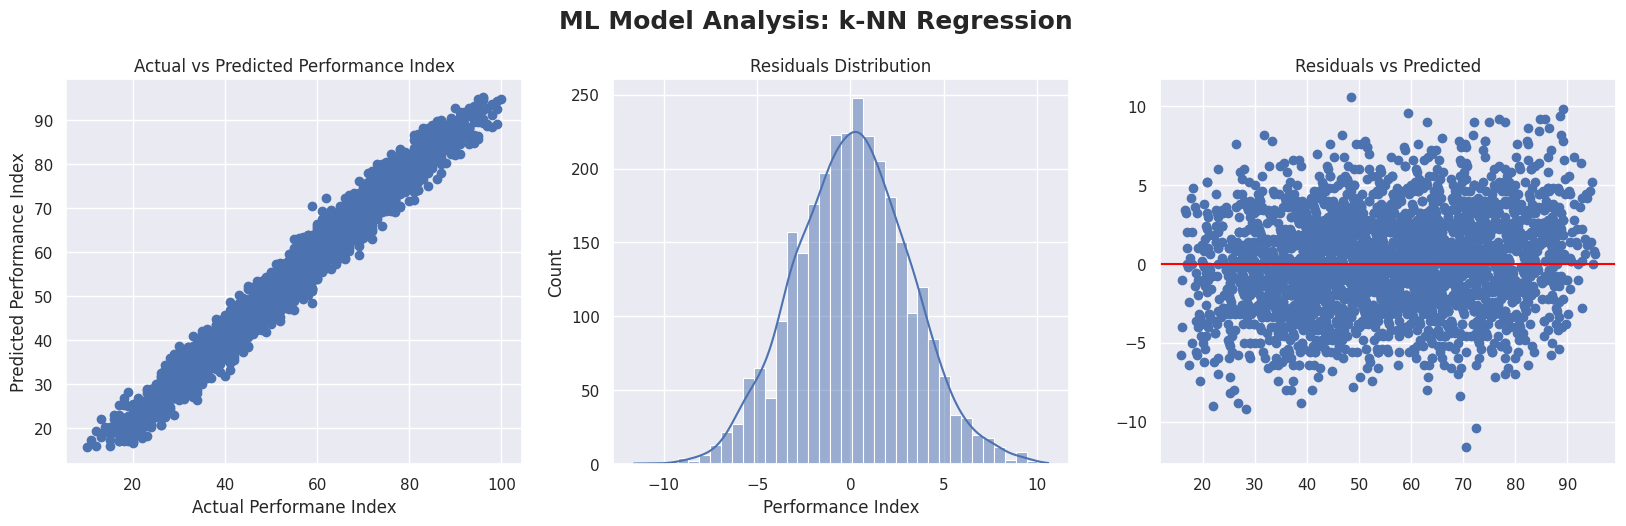

In [154]:
# Visualizing K-Nearest Neighbors Regression (k-NN)

plt.figure(figsize=(20,5))
plt.suptitle("ML Model Analysis: k-NN Regression", fontsize=18, fontweight='bold', y=1.02)

# Scatter Plot
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual Performane Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Performance Index")

# Calculate residuals
residuals_knn = y_test - y_pred_knn

# Histogram of residuals
plt.subplot(1,3,2)
sns.histplot(residuals_knn, kde=True)
plt.title("Residuals Distribution")

# Residuals vs Predicted
plt.subplot(1,3,3)
plt.scatter(y_pred_knn, residuals_knn)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted")
plt.show()

### Answer the follwing
1) Explain how Random Forest Regressor predicts a continuous value.
Include:
What is a decision tree regressor?
What is bootstrapping?
How multiple trees are used?
How final output is calculated?

# Answer
### What is a Decision Tree Regressor?

- A Decision Tree Regressor is a model that predicts a continuous value by splitting the data into smaller groups based on feature values. At each split, it chooses the feature and value that reduce error the most. At the final nodes (leaf nodes), it predicts the average value of the training data in that leaf. So, a single decision tree makes predictions by following a path of rules like:

                         If Age < 25 → If Income > 50k → Predict 72

### What is Bootstrapping?

- Bootstrapping means:

  1.   Randomly selecting samples from the original dataset
  2.   With replacement (some data points may appear multiple times, some not at all)

- Each decision tree in the forest is trained on a different bootstrapped dataset. This creates variety among the trees.

### How are Multiple Trees Used?

- Random Forest builds many decision trees (for example, 100 or 500 trees). It also:

  1. Uses bootstrapped datasets
  2. Randomly selects a subset of features at each split

- This makes each tree slightly different.

### How is the Final Output Calculated?

- For regression, each tree predicts a numerical value. The Random Forest takes the average of all tree predictions. So if 3 trees predict:

    Tree 1 → 50

    Tree 2 → 55

    Tree 3 → 52

    Final output: ( 50 + 55 + 52 ) / 3 = 52.33

### Why This Works Well?

- Reduces overfitting compared to a single tree
- Reduces variance
- More stable and accurate

### Answer the follwing

2) Explain how KNN Regressor predicts output for a new data point.
Include:
What is K?
How neighbors are selected?
How final predicted value is calculated?

# Answer
### What is K?

- K is the number of nearest neighbors used for prediction.

- Example:

    K = 3 → Use 3 closest data points
    
    K = 5 → Use 5 closest data points

- Choosing K:

    Small K → more sensitive to noise

    Large K → smoother prediction

### How Are Neighbors Selected?

1. Take the new data point

2. Calculate distance between it and all training points

Common distance:

    Euclidean distance

    Sort distances

    Pick the K smallest distances

These are the K nearest neighbors.

### How is Final Predicted Value Calculated?

- For regression, take the average of the target values of the K nearest neighbors.

- Example:

If K = 3 and nearest neighbors have target values:

    40

    50

    60

    Final prediction: ( 40 + 50 + 60 ) / 3 = 50



## Visualize Best Model

In [155]:
# Creating a Comparison Data Frame
results = [
    {
        "Model": "Linear Regression",
        "MAE": round(mae_lr, 4),
        "RMSE": round(rmse_lr, 4),
        "R2 Score": round(r2_lr, 4),
        "Training Time": f"{train_time_lr:.4f}s",
        "Testing Time": f"{test_time_lr:.4f}s"
    },
    {
        "Model": "SVR",
        "MAE": round(mae_svr, 4),
        "RMSE": round(rmse_svr, 4),
        "R2 Score": round(r2_svr, 4),
        "Training Time": f"{train_time_svr:.4f}s",
        "Testing Time": f"{test_time_svr:.4f}s"
    },
    {
        "Model": "Decision Tree",
        "MAE": round(mae_dt, 4),
        "RMSE": round(rmse_dt, 4),
        "R2 Score": round(r2_dt, 4),
        "Training Time": f"{train_time_dt:.4f}s",
        "Testing Time": f"{test_time_dt:.4f}s"
    },
    {
        "Model": "Random Forest",
        "MAE": round(mae_rf, 4),
        "RMSE": round(rmse_rf, 4),
        "R2 Score": round(r2_rf, 4),
        "Training Time": f"{train_time_rf:.4f}s",
        "Testing Time": f"{test_time_rf:.4f}s"
    },
    {
        "Model": "KNN",
        "MAE": round(mae_knn, 4),
        "RMSE": round(rmse_knn, 4),
        "R2 Score": round(r2_knn, 4),
        "Training Time": f"{train_time_knn:.4f}s",
        "Testing Time": f"{test_time_knn:.4f}s"
    }
]

comparison_df = pd.DataFrame(results)

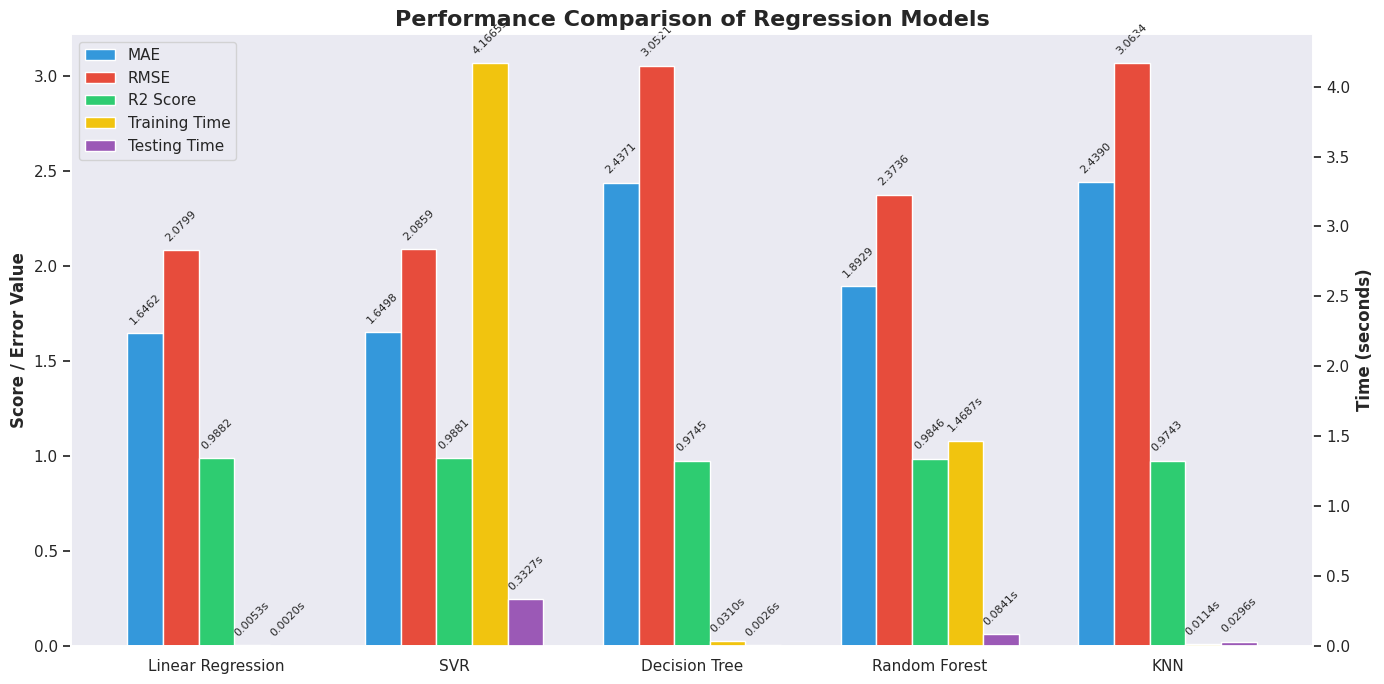

In [156]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the Data is numeric
for col in ['MAE', 'RMSE', 'R2 Score', 'Training Time', 'Testing Time']:
    if comparison_df[col].dtype == 'object':
        comparison_df[col] = comparison_df[col].astype(str).str.replace('s', '').astype(float)

models = comparison_df['Model']
x = np.arange(len(models))
width = 0.15

fig, ax1 = plt.subplots(figsize=(14, 7))

# Left Axis --- Score/Error Value
rects1 = ax1.bar(x - 2*width, comparison_df['MAE'], width, label='MAE', color='#3498db')
rects2 = ax1.bar(x - width, comparison_df['RMSE'], width, label='RMSE', color='#e74c3c')
rects3 = ax1.bar(x, comparison_df['R2 Score'], width, label='R2 Score', color='#2ecc71')

ax1.set_ylabel('Score / Error Value', fontweight='bold')
ax1.grid(False)

# Right Axis --- Time (seconds)
ax2 = ax1.twinx()
rects4 = ax2.bar(x + width, comparison_df['Training Time'], width, label='Training Time', color='#f1c40f')
rects5 = ax2.bar(x + 2*width, comparison_df['Testing Time'], width, label='Testing Time', color='#9b59b6')

ax2.set_ylabel('Time (seconds)', fontweight='bold')
ax2.grid(False)

ax1.set_title('Performance Comparison of Regression Models', fontsize=16, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

def autolabel(rects, ax, is_time=False):
    for rect in rects:
        height = rect.get_height()
        label = f'{height:.4f}' if not is_time else f'{height:.4f}s'
        ax.annotate(label,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=45)

autolabel(rects1, ax1)
autolabel(rects2, ax1)
autolabel(rects3, ax1)
autolabel(rects4, ax2, is_time=True)
autolabel(rects5, ax2, is_time=True)

plt.tight_layout()
plt.show()

## Generate a Comparison Table of Regression Models

Your output should look like this:

| Model | MAE | RMSE | R2 Score |Training Time|Testing Time|
|-------|-----|------|----------|-------------|------------|
| Linear Regression | | | |||
| SVR | | | |||
| Decision Tree | | | |||
| Random Forest | | | |||
| KNN | | | |||

---

In [157]:
# Comparison Table
print("Model Comparison Table:")
comparison_df.style.hide(axis='index')

Model Comparison Table:


Model,MAE,RMSE,R2 Score,Training Time,Testing Time
Linear Regression,1.646200,2.079900,0.988200,0.005300,0.002000
SVR,1.649800,2.085900,0.988100,4.166500,0.332700
Decision Tree,2.437100,3.052100,0.974500,0.031000,0.002600
Random Forest,1.892900,2.373600,0.984600,1.468700,0.084100
KNN,2.439000,3.063400,0.974300,0.011400,0.029600


In [158]:
# Selection of Best Model
# Define the metrics to evaluate
lower_is_better = ['MAE', 'RMSE', 'Training Time', 'Testing Time']
higher_is_better = ['R2 Score']

# Rank the models for each metric
ranks = pd.DataFrame(index=comparison_df.index)
for col in lower_is_better:
    ranks[col] = comparison_df[col].rank(ascending=True)
for col in higher_is_better:
    ranks[col] = comparison_df[col].rank(ascending=False)

# The model with the lowest average rank is the best overall performer
comparison_df['Average Rank'] = ranks.mean(axis=1)
best_model_idx = comparison_df['Average Rank'].idxmin()
best_model = comparison_df.loc[best_model_idx]

# Display the results
print("--- Model Selection Summary ---")
print(f"The Best Overall Model is: {best_model['Model']}")
print(f"Reasoning: Lowest average rank across all metrics.")
print("\nDetails of the Best Model:")
print(best_model.to_string())

# Highlight the best model in the dataframe
def highlight_best(s):
    is_best = s.name == best_model_idx
    return ['background-color: #2e7c71; color: white' if is_best else '' for _ in s]

comparison_df.style.apply(highlight_best, axis=1).hide(axis='index')

--- Model Selection Summary ---
The Best Overall Model is: Linear Regression
Reasoning: Lowest average rank across all metrics.

Details of the Best Model:
Model            Linear Regression
MAE                         1.6462
RMSE                        2.0799
R2 Score                    0.9882
Training Time               0.0053
Testing Time                 0.002
Average Rank                   1.0


Model,MAE,RMSE,R2 Score,Training Time,Testing Time,Average Rank
Linear Regression,1.646200,2.079900,0.988200,0.005300,0.002000,1.000000
SVR,1.649800,2.085900,0.988100,4.166500,0.332700,3.200000
Decision Tree,2.437100,3.052100,0.974500,0.031000,0.002600,3.400000
Random Forest,1.892900,2.373600,0.984600,1.468700,0.084100,3.400000
KNN,2.439000,3.063400,0.974300,0.011400,0.029600,4.000000
